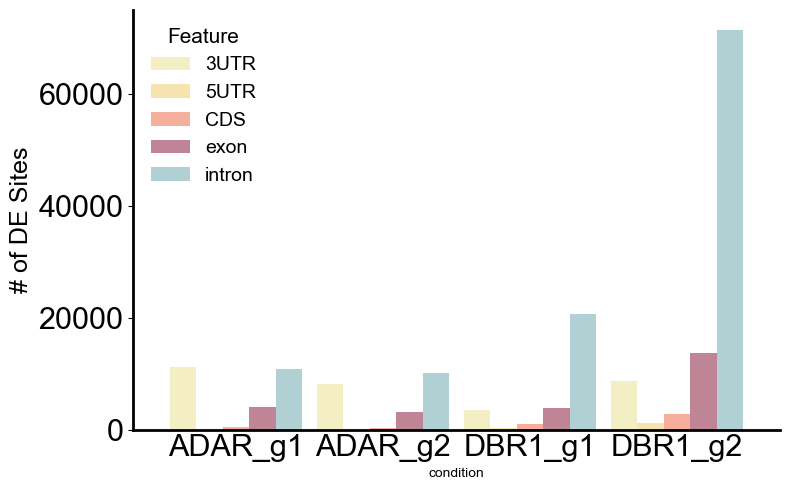

In [52]:
# import pandas as pd
# import pyranges as pr
# # This file contains the significant sites from the LoDEI Analysis with q < 0.01 and wEI inverted (as NTC was group 2 in the analysis)
# LoDEI_output = pd.read_csv('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_validation_ADAR_DBR1/LoDEI/significant_sites.csv', index_col=0)
# # Read in the GFF3 Annotation
# annotation = pr.read_gff3('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_validation_ADAR_DBR1/LoDEI/gencode.v48.chr_patch_hapl_scaff.annotation.gff3')
# genes     = annotation[annotation.Feature=="gene"]
# exons_all = annotation[annotation.Feature=="exon"]

# # helper to relabel a PyRanges
# def relabel(pr_obj, new_label):
#     df = pr_obj.df.copy()
#     df["Feature"] = new_label
#     return pr.PyRanges(df)

# # 2. Extract & relabel each category
# utr5       = relabel(annotation[annotation.Feature=="five_prime_UTR"],   "5UTR")
# utr3       = relabel(annotation[annotation.Feature=="three_prime_UTR"],  "3UTR")
# cds        = relabel(annotation[annotation.Feature=="CDS"],              "CDS")
# exons_all  = annotation[annotation.Feature=="exon"]
# # coding exons = exon minus any UTR
# coding_exons = relabel(
#     exons_all.subtract(utr5).subtract(utr3),
#     "exon"
# )
# genes      = annotation[annotation.Feature=="gene"]
# introns    = relabel(genes.subtract(exons_all),"intron")
# # 3. Build intergenic via complement (needs chrom.sizes)
# chrom_df = pd.read_csv(
#     "/tscc/projects/ps-malilab/utils/cellranger/refdata-gex-GRCh38-2024-A/fasta/chrom.sizes",
#     sep="\t",
#     header=None,
#     names=["Chromosome","Length"]
# )

# # 2) Build a PyRanges of full-chr intervals
# chrom_df["Start"] = 0
# chrom_df["End"]   = chrom_df["Length"]
# chr_ranges = pr.PyRanges(chrom_df[["Chromosome","Start","End"]])
# intergenic  = relabel(chr_ranges.subtract(genes),"intergenic")

# # 4. Concatenate into a disjoint master track
# master = pr.concat([utr5, utr3, cds, coding_exons, introns, intergenic])

# # 5. Load & prep your LoDEI sites
# LoDEI_output = LoDEI_output.rename(columns={"chrom":"Chromosome","wstart":"Start","wend":"End"})
# LoDEI_output["Start"] = LoDEI_output["Start"] - 1
# sites = pr.PyRanges(LoDEI_output)

# # 6. Join → one row per site
# annotated = sites.join(master, how="left")
# annotated = annotated.df

# # For each site (Chromosome, Start, End, name, condition), keep the row with the most specific Feature (priority: CDS > 5UTR/3UTR > exon > intron > intergenic)
# feature_priority = {
#     "CDS": 0,
#     "5' UTR": 1,
#     "3' UTR": 1,
#     "Exon": 2,
#     "Intron": 3,
#     "Intergenic": 4
# }
# annotated["feature_rank"] = annotated["Feature"].map(feature_priority)
# # If Feature is missing or not in the list, assign lowest priority
# annotated["feature_rank"] = annotated["feature_rank"].fillna(5)
# # Sort so that the most specific feature comes first, then by original order
# annotated_sorted = annotated.sort_values(
#     by=["Chromosome", "Start", "End", "name", "condition", "feature_rank"]
# )
# # Drop duplicates, keeping the most specific feature per site
# annotated_filtered = annotated_sorted.drop_duplicates(
#     subset=["Chromosome", "Start", "End", "name", "condition"], keep="first"
# ).drop(columns="feature_rank")
# annotated_filtered.head()

# import matplotlib.pyplot as plt

# # Get counts per feature per condition
# feature_counts = annotated_filtered.groupby(['condition', 'Feature']).size().unstack(fill_value=0)

# Define custom colors for the features (order must match columns)
custom_colors = ['#B0D0D3', '#C08497', '#F7AF9D', '#F7E3AF', '#F3EEC3']
# If the number of features is less than 5, slice the color list
colors = custom_colors[:feature_counts.shape[1]]

fig, ax = plt.subplots(figsize=(8, 5))

# Plot with improved aesthetics
bars = feature_counts.plot(
    kind='bar',
    stacked=False,
    ax=ax,
    color=colors[::-1],
    width=.9,  # Make bars closer together
)

# Only show lines on x and y axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
# Set larger font sizes
ax.set_ylabel('# of DE Sites', fontsize=18)
ax.tick_params(axis='x', labelsize=22,  length=0)
ax.tick_params(axis='y', labelsize=22,)
for spine in ax.spines.values():
    spine.set_linewidth(2)


# Adjust legend
legend = ax.legend(title='Feature', fontsize=14, title_fontsize=15, frameon=False)
plt.xticks(rotation=0, ha='center')

plt.tight_layout()
plt.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_validation_ADAR_DBR1/LoDEI/editing_per_feature.svg')
plt.show()

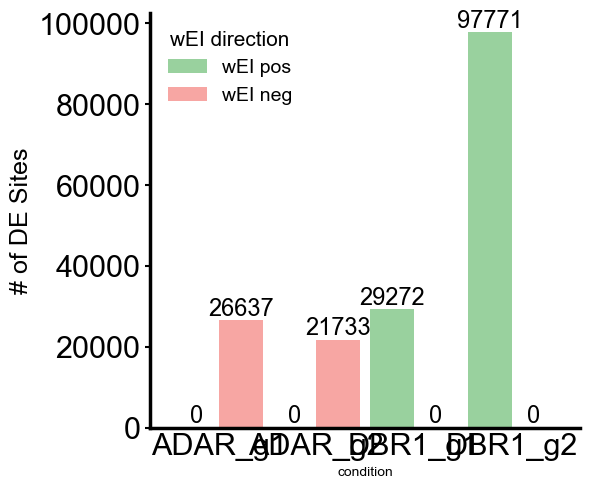

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'

# Create a new column for wEI direction
annotated_filtered['wEI_direction'] = annotated_filtered['wEI'].apply(lambda x: 'wEI pos' if x > 0 else 'wEI neg')

# Count number of wEI pos and wEI neg per condition
wei_counts = annotated_filtered.groupby(['condition', 'wEI_direction']).size().unstack(fill_value=0)

# Define custom colors for up (wEI pos) and down (wEI neg)
colors = ['#99D19E', '#F7A6A3']  # [wEI pos, wEI neg]
# Ensure columns are in the right order
wei_counts = wei_counts.reindex(columns=['wEI pos', 'wEI neg'], fill_value=0)

fig, ax = plt.subplots(figsize=(8,5))

bars = wei_counts.plot(
    kind='bar',
    stacked=False,
    ax=ax,
    color=colors,
    width=.9,
    linewidth=3,  # Make the bar edge lines thicker
)

# Make the axis lines thicker
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Add numbers on top of the bars, including zeros
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=17,
    )

ax.set_ylabel('# of DE Sites', fontsize=18)
ax.tick_params(axis='x', labelsize=22, length=0, width=1.5)
ax.tick_params(axis='y', labelsize=22, width=1.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

legend = ax.legend(title='wEI direction', fontsize=14, title_fontsize=15, frameon=False)
plt.xticks(rotation=0, ha='center')

plt.tight_layout()
plt.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_validation_ADAR_DBR1/LoDEI/number_of_sites_per_feature.svg')
plt.show()

<Figure size 1000x800 with 0 Axes>

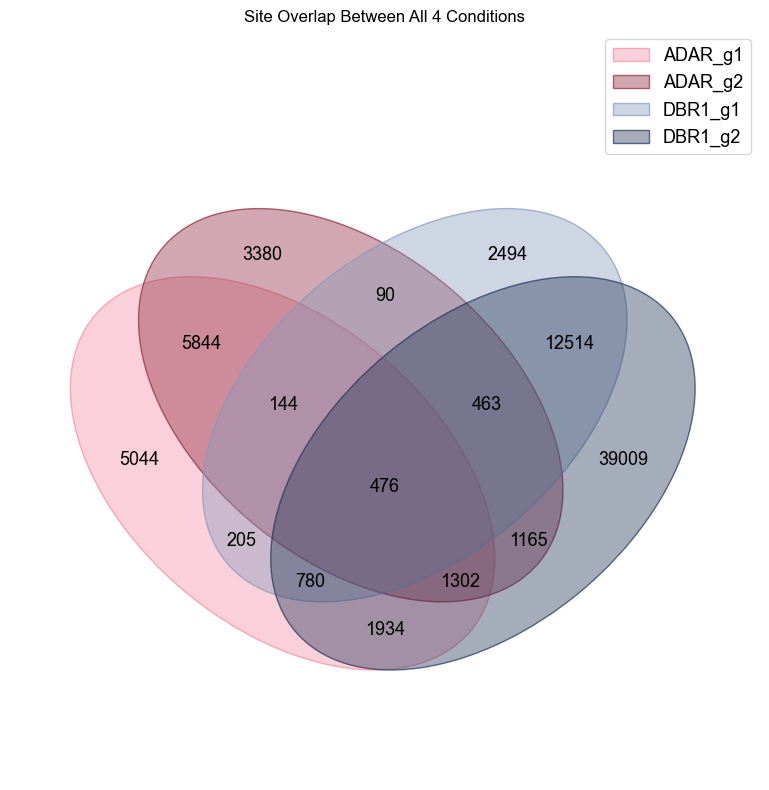

In [3]:
# First, install the venn package if you haven't already:
# pip install venn

import pandas as pd
from venn import venn
import matplotlib.pyplot as plt

# ———————— Load or assume your annotated_filtered DataFrame ————————
# For example, if it’s in a CSV:
# annotated_filtered = pd.read_csv("annotated_filtered.csv")

# Or if you already have it in your session, skip the above.

# ———————— Identify your site identifier columns ————————
site_id_cols = ['Chromosome', 'Start', 'End', 'Strand']

# ———————— Extract the unique conditions ————————
conditions = annotated_filtered['condition'].unique()
if len(conditions) != 4:
    raise ValueError(f"Expected 4 conditions but found {len(conditions)}: {conditions}")

# ———————— Build a dict mapping each condition to its set of site IDs ————————
sets_dict = {}
for cond in conditions:
    df_sub = annotated_filtered[annotated_filtered['condition'] == cond]
    # tuple of (Chrom, Start, End, Strand) per row
    site_ids = set(map(tuple, df_sub[site_id_cols].values))
    sets_dict[cond] = site_ids

# ———————— Plot the 4-way Venn with custom colors ————————
plt.figure(figsize=(10, 8))
venn(
    sets_dict,
    cmap=[ "#F38CA3", "#8D263D", "#8699BB", "#203255" ]
)
plt.title("Site Overlap Between All 4 Conditions")
plt.tight_layout()
plt.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_validation_ADAR_DBR1/LoDEI/site_overlap_venn_diagram.svg')
plt.show()


In [101]:
# From the venn, get where all 4 categories overlap and display that df

# Use the same site_id_cols as in the venn
site_id_cols = ['Chromosome', 'Start', 'End', 'Strand']

# Get the unique conditions (should be 4)
conditions = annotated_filtered['condition'].unique()
if len(conditions) != 4:
    raise ValueError(f"Expected 4 conditions but found {len(conditions)}: {conditions}")

# Build a dict mapping each condition to its set of site IDs (as in the venn)
sets_dict = {}
for cond in conditions:
    df_sub = annotated_filtered[annotated_filtered['condition'] == cond]
    site_ids = set(map(tuple, df_sub[site_id_cols].values))
    sets_dict[cond] = site_ids

# Get the intersection (overlap) of all 4 sets
overlap_sites = set.intersection(*sets_dict.values())

# Display the dataframe rows corresponding to the overlap
overlap_df = annotated_filtered[
    annotated_filtered.apply(lambda row: tuple(row[site_id_cols]) in overlap_sites, axis=1)
]

display(overlap_df)

,Chromosome,Start,End,name,wEI,strand,q_value,condition,Source,Feature,...,exon_id,transcript_support_level,havana_transcript,hgnc_id,havana_gene,ont,protein_id,ccdsid,artif_dupl,wEI_direction
8,KI270734.1,149362,149413,84053,-48.2,-,0.005,ADAR_g1,ENSEMBL,intron,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wEI neg
10,KI270734.1,149362,149413,84053,-41.6,-,0.006,ADAR_g2,ENSEMBL,intron,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wEI neg
14,KI270734.1,149362,149413,84053,50.3,-,0.001,DBR1_g1,ENSEMBL,intron,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wEI pos
20,KI270734.1,149362,149413,84053,56.9,-,0.000,DBR1_g2,ENSEMBL,intron,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wEI pos
9,KI270734.1,149362,149413,84081,-48.2,-,0.005,ADAR_g1,ENSEMBL,intron,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,wEI neg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372212,chrY,12666831,12666882,79918,137.5,+,0.000,DBR1_g2,HAVANA,intron,...,NaN,NaN,NaN,HGNC:12633,OTTHUMG00000036469.3,NaN,NaN,NaN,NaN,wEI pos
371885,chrY,12666842,12666893,79892,-60.9,+,0.003,ADAR_g1,HAVANA,intron,...,NaN,NaN,NaN,HGNC:12633,OTTHUMG00000036469.3,NaN,NaN,NaN,NaN,wEI neg
371989,chrY,12666842,12666893,79892,-56.1,+,0.004,ADAR_g2,HAVANA,intron,...,NaN,NaN,NaN,HGNC:12633,OTTHUMG00000036469.3,NaN,NaN,NaN,NaN,wEI neg
372068,chrY,12666842,12666893,79892,54.5,+,0.001,DBR1_g1,HAVANA,intron,...,NaN,NaN,NaN,HGNC:12633,OTTHUMG00000036469.3,NaN,NaN,NaN,NaN,wEI pos


In [44]:
overlap_df.Feature.value_counts()

Feature
intron    2160
3UTR       704
exon       316
5UTR        36
CDS         20
Name: count, dtype: int64

In [81]:
overlap_df[overlap_df.Feature == "intron"].sort_values(by='wEI').tail(20)

,Chromosome,Start,End,name,wEI,strand,q_value,condition,Source,Feature,...,exon_id,transcript_support_level,havana_transcript,hgnc_id,havana_gene,ont,protein_id,ccdsid,artif_dupl,wEI_direction
239210,chr15,58885689,58885740,76700,209.4,-,0.0,DBR1_g2,HAVANA,intron,...,NaN,NaN,NaN,HGNC:17384,OTTHUMG00000132716.3,NaN,NaN,NaN,NaN,wEI pos
239183,chr15,58885689,58885740,76591,209.4,-,0.0,DBR1_g2,HAVANA,intron,...,NaN,NaN,NaN,HGNC:17384,OTTHUMG00000132716.3,NaN,NaN,NaN,NaN,wEI pos
146680,chr7,75593104,75593155,37924,211.4,-,0.0,DBR1_g2,HAVANA,intron,...,NaN,NaN,NaN,HGNC:4913,OTTHUMG00000156050.6,NaN,NaN,NaN,NaN,wEI pos
236166,chr15,40213647,40213698,48423,213.9,+,0.0,DBR1_g2,HAVANA,intron,...,NaN,NaN,NaN,HGNC:1149,OTTHUMG00000129877.4,NaN,NaN,NaN,NaN,wEI pos
236194,chr15,40213647,40213698,48493,213.9,+,0.0,DBR1_g2,HAVANA,intron,...,NaN,NaN,NaN,HGNC:1149,OTTHUMG00000129877.4,NaN,NaN,NaN,NaN,wEI pos
236189,chr15,40213647,40213698,48470,213.9,+,0.0,DBR1_g2,HAVANA,intron,...,NaN,NaN,NaN,HGNC:1149,OTTHUMG00000129877.4,NaN,NaN,NaN,NaN,wEI pos
236171,chr15,40213647,40213698,48446,213.9,+,0.0,DBR1_g2,HAVANA,intron,...,NaN,NaN,NaN,HGNC:1149,OTTHUMG00000129877.4,NaN,NaN,NaN,NaN,wEI pos
239204,chr15,58885663,58885714,76696,221.2,-,0.0,DBR1_g2,HAVANA,intron,...,NaN,NaN,NaN,HGNC:17384,OTTHUMG00000132716.3,NaN,NaN,NaN,NaN,wEI pos
317015,chr19,2133668,2133719,36275,225.4,-,0.0,DBR1_g2,HAVANA,intron,...,NaN,NaN,NaN,HGNC:568,OTTHUMG00000180354.6,NaN,NaN,NaN,NaN,wEI pos
239193,chr15,58885656,58885707,76661,237.3,-,0.0,DBR1_g2,HAVANA,intron,...,NaN,NaN,NaN,HGNC:17384,OTTHUMG00000132716.3,NaN,NaN,NaN,NaN,wEI pos


In [52]:
overlap_df_sorted = overlap_df.sort_values(by='wEI')
display(overlap_df_sorted)


,Chromosome,Start,End,name,wEI,strand,q_value,condition,Source,Feature,...,exon_id,transcript_support_level,havana_transcript,hgnc_id,havana_gene,ont,protein_id,ccdsid,artif_dupl,wEI_direction
175737,chr10,17687312,17687363,77403,-213.5,+,0.003,ADAR_g1,HAVANA,intron,...,NaN,NaN,NaN,HGNC:11357,OTTHUMG00000017749.4,NaN,NaN,NaN,NaN,wEI neg
175730,chr10,17687312,17687363,77392,-213.5,+,0.003,ADAR_g1,HAVANA,intron,...,NaN,NaN,NaN,HGNC:11357,OTTHUMG00000017749.4,NaN,NaN,NaN,NaN,wEI neg
288059,chr19,1035719,1035770,30795,-211.5,+,0.003,ADAR_g1,HAVANA,intron,...,NaN,NaN,NaN,HGNC:2156,OTTHUMG00000172729.9,NaN,NaN,NaN,NaN,wEI neg
288074,chr19,1035719,1035770,30802,-211.5,+,0.003,ADAR_g1,HAVANA,intron,...,NaN,NaN,NaN,HGNC:2156,OTTHUMG00000172729.9,NaN,NaN,NaN,NaN,wEI neg
288091,chr19,1035718,1035769,30805,-204.3,+,0.003,ADAR_g1,HAVANA,intron,...,NaN,NaN,NaN,HGNC:2156,OTTHUMG00000172729.9,NaN,NaN,NaN,NaN,wEI neg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9261,chr1,39002556,39002607,60629,259.6,+,0.000,DBR1_g2,HAVANA,intron,...,NaN,NaN,NaN,HGNC:25744,OTTHUMG00000007496.3,NaN,NaN,NaN,NaN,wEI pos
9325,chr1,39002521,39002572,60658,262.7,+,0.000,DBR1_g2,HAVANA,intron,...,NaN,NaN,NaN,HGNC:25744,OTTHUMG00000007496.3,NaN,NaN,NaN,NaN,wEI pos
316932,chr19,2133656,2133707,36175,262.9,-,0.000,DBR1_g2,HAVANA,intron,...,NaN,NaN,NaN,HGNC:568,OTTHUMG00000180354.6,NaN,NaN,NaN,NaN,wEI pos
316958,chr19,2133671,2133722,36222,262.9,-,0.000,DBR1_g2,HAVANA,intron,...,NaN,NaN,NaN,HGNC:568,OTTHUMG00000180354.6,NaN,NaN,NaN,NaN,wEI pos


In [53]:
overlap_df_sorted.iloc[-1]

Chromosome                                 chr19
Start                                    2133661
End                                      2133712
name                                       36270
wEI                                        263.3
strand                                         -
q_value                                      0.0
condition                                DBR1_g2
Source                                    HAVANA
Feature                                   intron
Start_b                                  2133484
End_b                                    2137010
Score                                          .
Strand                                         -
Frame                                          .
ID                            ENSG00000065000.20
gene_id                       ENSG00000065000.20
gene_type                         protein_coding
gene_name                                  AP3D1
level                                          2
tag                 

In [82]:
overlap_df_chr19_site = overlap_df[
    (overlap_df['Chromosome'] == 'chr1') &
    (overlap_df['Start'] == 39002521) &
    (overlap_df['End'] == 39002572)
]
display(overlap_df_chr19_site)

,Chromosome,Start,End,name,wEI,strand,q_value,condition,Source,Feature,...,exon_id,transcript_support_level,havana_transcript,hgnc_id,havana_gene,ont,protein_id,ccdsid,artif_dupl,wEI_direction
602,chr1,39002521,39002572,60658,-55.2,+,0.003,ADAR_g1,HAVANA,intron,...,NaN,NaN,NaN,HGNC:25744,OTTHUMG00000007496.3,NaN,NaN,NaN,NaN,wEI neg
3877,chr1,39002521,39002572,60658,-37.3,+,0.007,ADAR_g2,HAVANA,intron,...,NaN,NaN,NaN,HGNC:25744,OTTHUMG00000007496.3,NaN,NaN,NaN,NaN,wEI neg
5725,chr1,39002521,39002572,60658,197.5,+,0.001,DBR1_g1,HAVANA,intron,...,NaN,NaN,NaN,HGNC:25744,OTTHUMG00000007496.3,NaN,NaN,NaN,NaN,wEI pos
9325,chr1,39002521,39002572,60658,262.7,+,0.000,DBR1_g2,HAVANA,intron,...,NaN,NaN,NaN,HGNC:25744,OTTHUMG00000007496.3,NaN,NaN,NaN,NaN,wEI pos


In [83]:
overlap_df_chr19_site.gene_name.value_counts()

gene_name
AKIRIN1    4
Name: count, dtype: int64

In [103]:
annotated_filtered.to_csv('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_validation_ADAR_DBR1/LoDEI/annotated_significant_sites_with_feature.csv')

In [104]:
overlap_df.to_csv('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_validation_ADAR_DBR1/LoDEI/site_overlap_df.csv')

In [2]:
import pandas as pd

# Read and flip wEI for all 4 datasets
lodei_windows_adar_g1 = pd.read_csv('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_validation_ADAR_DBR1/LoDEI/ADAR_v_NTC_g1/windows/windows_AG.txt', sep='\t')
lodei_windows_adar_g1['wEI'] = lodei_windows_adar_g1['wEI'] * -1

lodei_windows_adar_g2 = pd.read_csv('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_validation_ADAR_DBR1/LoDEI/ADAR_v_NTC_g2/windows/windows_AG.txt', sep='\t')
lodei_windows_adar_g2['wEI'] = lodei_windows_adar_g2['wEI'] * -1

lodei_windows_dbr1_g1 = pd.read_csv('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_validation_ADAR_DBR1/LoDEI/DBR_v_NTC_g1/windows/windows_AG.txt', sep='\t')
lodei_windows_dbr1_g1['wEI'] = lodei_windows_dbr1_g1['wEI'] * -1

lodei_windows_dbr1_g2 = pd.read_csv('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_validation_ADAR_DBR1/LoDEI/DBR_v_NTC_g2/windows/windows_AG.txt', sep='\t')
lodei_windows_dbr1_g2['wEI'] = lodei_windows_dbr1_g2['wEI'] * -1

# To avoid column name collisions, rename wEI and q_value columns before merging
lodei_windows_adar_g1 = lodei_windows_adar_g1.rename(columns={'wEI': 'wEI_adar_g1', 'q_value': 'q_value_adar_g1'})
lodei_windows_adar_g2 = lodei_windows_adar_g2.rename(columns={'wEI': 'wEI_adar_g2', 'q_value': 'q_value_adar_g2'})
lodei_windows_dbr1_g1 = lodei_windows_dbr1_g1.rename(columns={'wEI': 'wEI_dbr1_g1', 'q_value': 'q_value_dbr1_g1'})
lodei_windows_dbr1_g2 = lodei_windows_dbr1_g2.rename(columns={'wEI': 'wEI_dbr1_g2', 'q_value': 'q_value_dbr1_g2'})

# Merge all 4 datasets on chrom, wstart, wend, name, strand
merge_cols = ['chrom', 'wstart', 'wend', 'name', 'strand']
intersected_all = lodei_windows_adar_g1.merge(
    lodei_windows_adar_g2[merge_cols + ['wEI_adar_g2', 'q_value_adar_g2']],
    on=merge_cols, how='inner'
).merge(
    lodei_windows_dbr1_g1[merge_cols + ['wEI_dbr1_g1', 'q_value_dbr1_g1']],
    on=merge_cols, how='inner'
).merge(
    lodei_windows_dbr1_g2[merge_cols + ['wEI_dbr1_g2', 'q_value_dbr1_g2']],
    on=merge_cols, how='inner'
)

# Select and order columns for clarity
intersected_all = intersected_all[
    ['chrom', 'wstart', 'wend', 'name', 'strand',
     'wEI_adar_g1', 'q_value_adar_g1',
     'wEI_adar_g2', 'q_value_adar_g2',
     'wEI_dbr1_g1', 'q_value_dbr1_g1',
     'wEI_dbr1_g2', 'q_value_dbr1_g2']
]

intersected_all

,chrom,wstart,wend,name,strand,wEI_adar_g1,q_value_adar_g1,wEI_adar_g2,q_value_adar_g2,wEI_dbr1_g1,q_value_dbr1_g1,wEI_dbr1_g2,q_value_dbr1_g2
0,chr1,14684,14734,1,+,0.1,0.620,-0.5,0.538,-0.5,0.652,-0.5,0.684
1,chr1,14735,14785,1,+,-0.0,1.000,1.0,0.485,1.2,0.535,0.7,0.572
2,chr1,14786,14836,1,+,-0.0,1.000,0.7,0.522,-0.0,1.000,-0.0,1.000
3,chr1,14608,14658,4,+,3.7,0.340,-0.0,1.000,-0.0,1.000,-0.0,1.000
4,chr1,14659,14709,4,+,1.1,0.462,-0.1,0.613,-0.5,0.652,2.0,0.381
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4252142,KI270734.1,161324,161374,84110,-,-0.7,0.499,-0.7,0.504,-0.7,0.620,-0.7,0.657
4252143,KI270734.1,161375,161425,84110,-,8.6,0.321,0.2,0.608,-1.8,0.525,-2.5,0.524
4252144,KI270734.1,161426,161476,84110,-,1.2,0.454,0.5,0.554,-0.0,1.000,-0.0,1.000
4252145,KI270734.1,161477,161527,84110,-,-0.0,1.000,-0.0,1.000,-0.0,1.000,-0.0,1.000


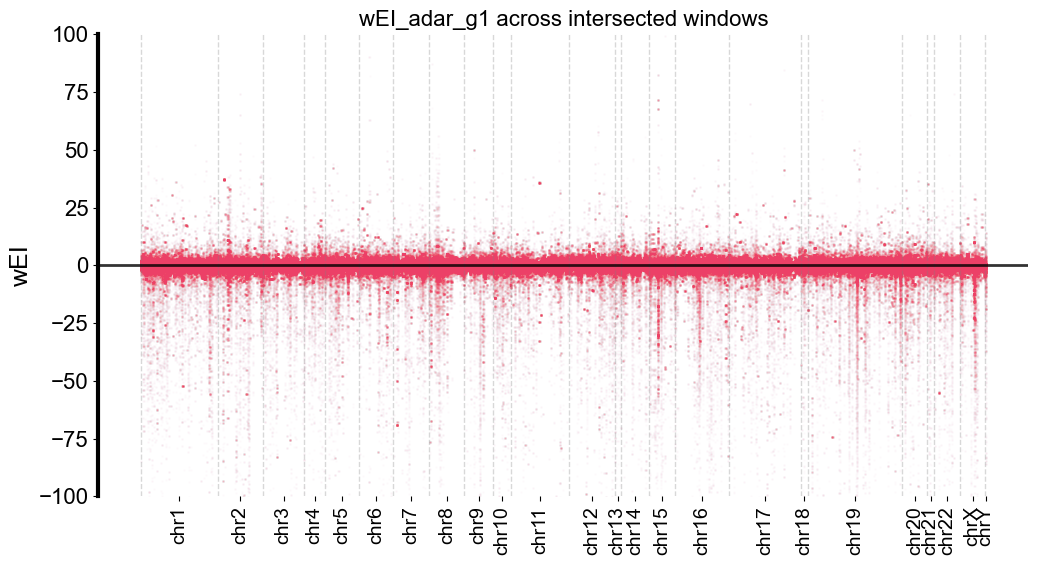

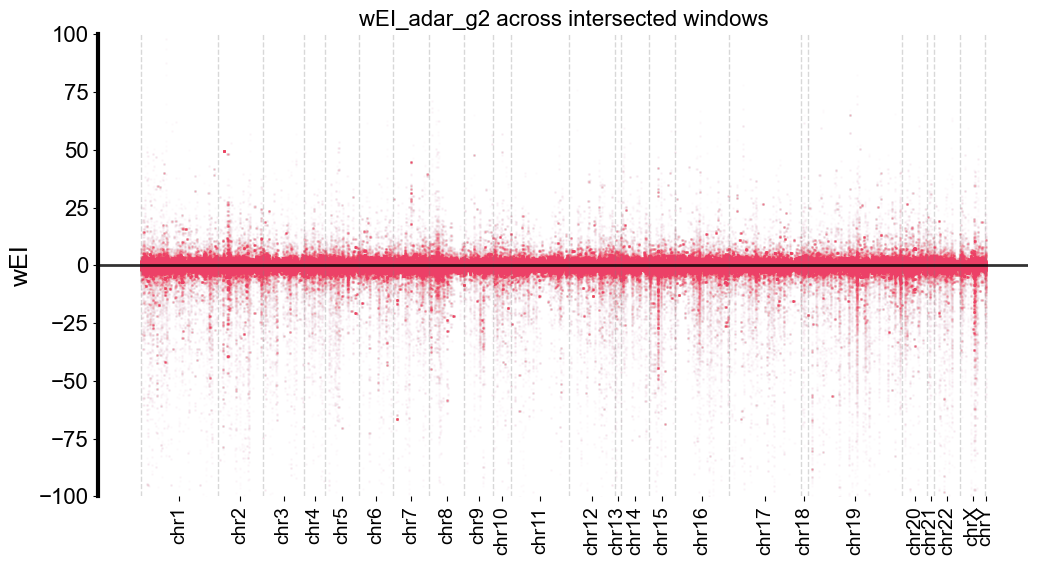

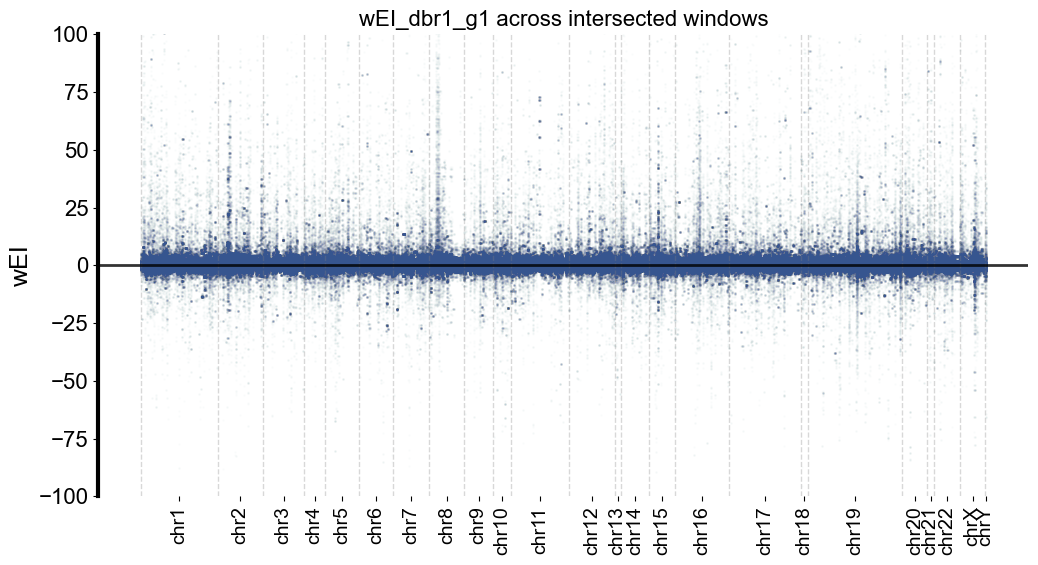

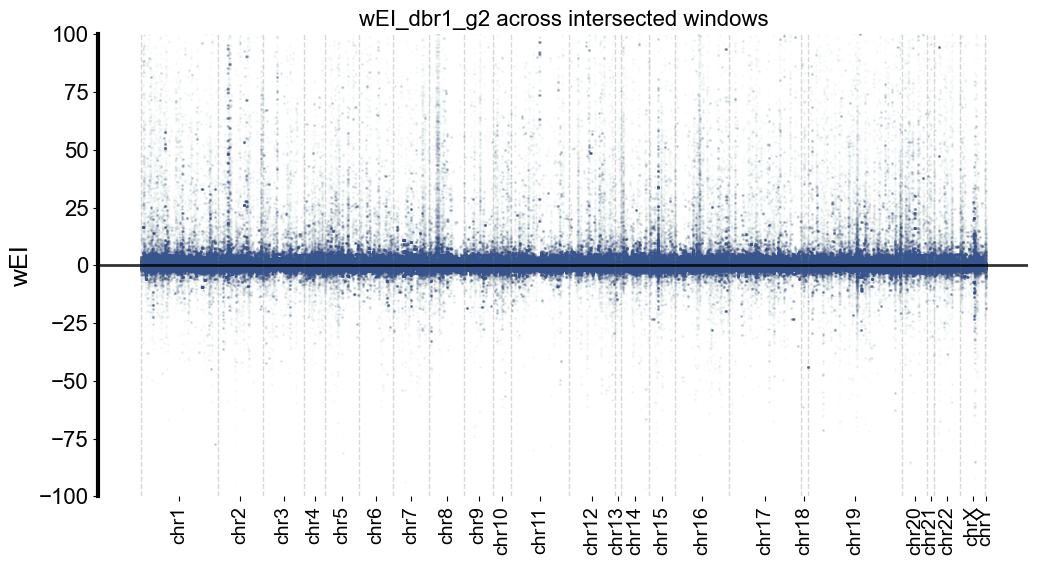

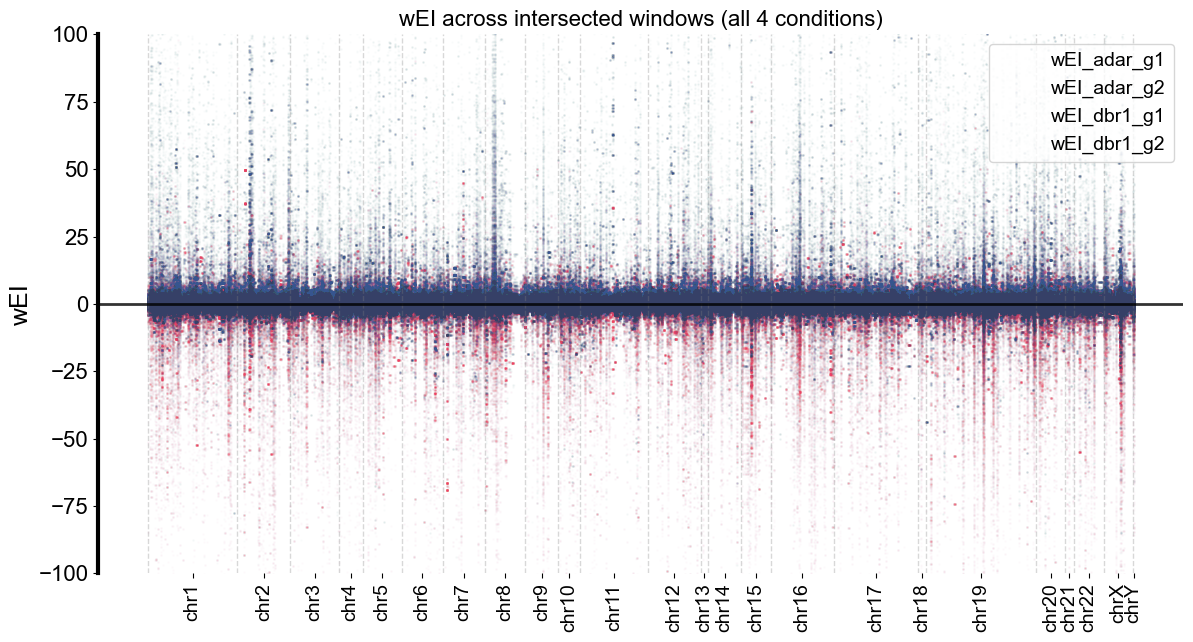

In [3]:
plt.rcParams['font.family'] = 'Arial'

# Prepare the data up to and including ChrY
chroms = intersected_all['chrom']
if (chroms == 'chrY').any():
    last_chrY_idx = chroms[chroms == 'chrY'].index[-1]
    intersected_plot = intersected_all.loc[:last_chrY_idx]
else:
    intersected_plot = intersected_all.copy()

# Find chromosome change indices and labels for annotation
chroms_plot = intersected_plot['chrom']
chrom_change_indices = intersected_plot.index[chroms_plot != chroms_plot.shift()].tolist()
chrom_labels = chroms_plot.iloc[chrom_change_indices].tolist()
chrom_boundaries = chrom_change_indices + [intersected_plot.index[-1] + 1]
chrom_label_positions = []
for i in range(len(chrom_boundaries) - 1):
    start = chrom_boundaries[i]
    end = chrom_boundaries[i+1]
    mid = (start + end) // 2
    chrom_label_positions.append(mid)

# Plot all 4 conditions separately
condition_plot_info = [
    ('wEI_adar_g1', '#EC4067', 'wEI_adar_g1', (-100, 100)),
    ('wEI_adar_g2', '#EC4067', 'wEI_adar_g2', (-100, 100)),
    ('wEI_dbr1_g1', '#36558F', 'wEI_dbr1_g1', (-100, 100)),
    ('wEI_dbr1_g2', '#36558F', 'wEI_dbr1_g2', (-100, 100)),
]

for col, color, label, ylim in condition_plot_info:
    plt.figure(figsize=(12, 6))
    plt.scatter(intersected_plot.index, intersected_plot[col], s=1, alpha=0.01, color=color, label=label)
    plt.ylabel('wEI', fontsize=18)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_linewidth(3)
    plt.ylim(*ylim)
    plt.yticks(fontsize=16)
    plt.xticks(fontsize=16)
    plt.xticks(chrom_label_positions, chrom_labels, rotation=90, fontsize=14)
    for x in chrom_change_indices:
        plt.axvline(x=x, color='gray', linestyle='--', linewidth=1, alpha=0.3)
    plt.axhline(y=0, color='black', linewidth=2, alpha=0.8)
    plt.title(f'{label} across intersected windows', fontsize=16)
    plt.show()

# Overlay plot: all 4 conditions
plt.figure(figsize=(14, 7))
for col, color, label, ylim in condition_plot_info:
    plt.scatter(intersected_plot.index, intersected_plot[col], s=1, alpha=0.01, color=color, label=label)
plt.ylabel('wEI', fontsize=18)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_linewidth(3)
plt.ylim(-100, 100)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
plt.xticks(chrom_label_positions, chrom_labels, rotation=90, fontsize=14)
for x in chrom_change_indices:
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=1, alpha=0.3)
plt.axhline(y=0, color='black', linewidth=2, alpha=0.8)
plt.legend(fontsize=14, loc='upper right')
plt.title('wEI across intersected windows (all 4 conditions)', fontsize=16)
plt.show()


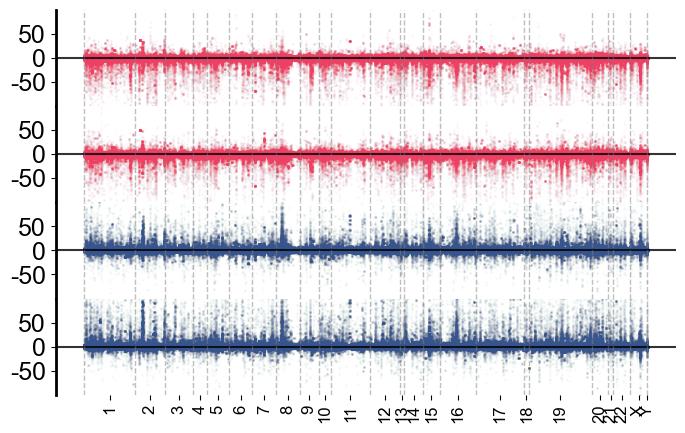

In [4]:
import matplotlib.pyplot as plt

# Create a 4-row subplot with shared x-axis
fig, axes = plt.subplots(4, 1, figsize=(8, 5), sharex=True, gridspec_kw={'hspace': 0.00})

for i, (col, color, label, ylim) in enumerate(condition_plot_info):
    ax = axes[i]
    ax.scatter(intersected_plot.index, intersected_plot[col], s=1, alpha=0.01, color=color, label=label)
    ax.set_ylim(*ylim)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Turn off the x axis line at the very bottom plot
    if i == 3:
        ax.spines['bottom'].set_visible(False)
    else:
        ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    # Set y-ticks to only -50, 0, 50 for each plot
    ax.set_yticks([-50, 0, 50])
    ax.set_yticklabels(['-50', '0', '50'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.axhline(y=0, color='black', linewidth=1.5, alpha=0.8)
    # Chromosome delineation lines
    for x in chrom_change_indices:
        ax.axvline(x=x, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    if i < 3:
        ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    else:
        ax.set_xticks(chrom_label_positions)
        ax.set_xticklabels([label.replace('chr', '') for label in chrom_labels], rotation=90, fontsize=12)
        ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=18)
#plt.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_validation_ADAR_DBR1/LoDEI/lodei_tracks.png', dpi=1200)
plt.show()



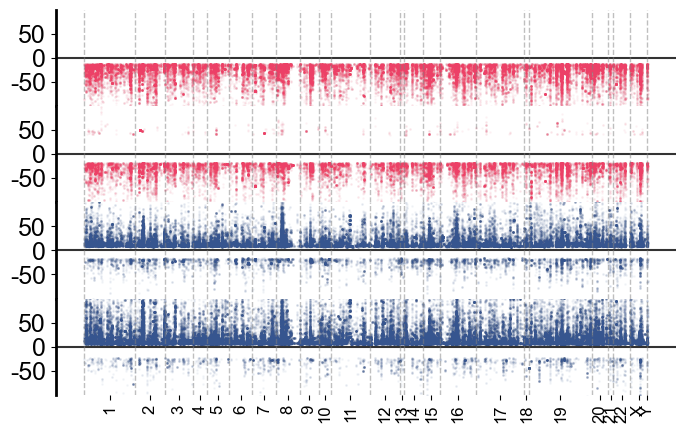

In [5]:
import matplotlib.pyplot as plt

# Create a 4-row subplot with shared x-axis
fig, axes = plt.subplots(4, 1, figsize=(8, 5), sharex=True, gridspec_kw={'hspace': 0.00})

for i, (col, color, label, ylim) in enumerate(condition_plot_info):
    ax = axes[i]
    # Only plot sites with q < 0.01 for each condition
    q_col = f"q_value_{col.split('_')[1]}_{col.split('_')[2]}" if col.startswith("wEI_") else None
    if q_col and q_col in intersected_plot.columns:
        mask = intersected_plot[q_col] < 0.1
    else:
        # fallback: try to find a q-value column for this condition
        # assumes col is like 'wEI_adar_g1', so q_col is 'q_value_adar_g1'
        q_col = "q_value_" + "_".join(col.split('_')[1:])
        if q_col in intersected_plot.columns:
            mask = intersected_plot[q_col] < 0.2
        else:
            # fallback: if no q-value column, plot nothing
            mask = [False] * len(intersected_plot)
    ax.scatter(intersected_plot.index[mask], intersected_plot[col][mask], s=1, alpha=0.04, color=color, label=label)
    ax.set_ylim(*ylim)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Turn off the x axis line at the very bottom plot
    if i == 3:
        ax.spines['bottom'].set_visible(False)
    else:
        ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    # Set y-ticks to only -50, 0, 50 for each plot
    ax.set_yticks([-50, 0, 50])
    ax.set_yticklabels(['-50', '0', '50'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.axhline(y=0, color='black', linewidth=1.5, alpha=0.8)
    # Chromosome delineation lines
    for x in chrom_change_indices:
        ax.axvline(x=x, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    if i < 3:
        ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    else:
        ax.set_xticks(chrom_label_positions)
        ax.set_xticklabels([label.replace('chr', '') for label in chrom_labels], rotation=90, fontsize=12)
        ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=18)
plt.savefig('/tscc/projects/ps-malilab/ydoctor/KOLF_Perturbation_Atlas/alu_editing/AEI_validation_ADAR_DBR1/LoDEI/lodei_tracks_significant.png', dpi=1200)
plt.show()


In [60]:
# Print the number of sites for each sample with wEI > 0 and < 0, using the same significance cutoff as the above plot

for col in ['wEI_adar_g1', 'wEI_adar_g2', 'wEI_dbr1_g1', 'wEI_dbr1_g2']:
    if col in intersected_plot.columns:
        # Determine the q-value column for this wEI column
        q_col = f"q_value_{col.split('_')[1]}_{col.split('_')[2]}" if col.startswith("wEI_") else None
        if q_col and q_col in intersected_plot.columns:
            sig_mask = intersected_plot[q_col] < 0.1
        else:
            # fallback: try to find a q-value column for this condition
            q_col = "q_value_" + "_".join(col.split('_')[1:])
            if q_col in intersected_plot.columns:
                sig_mask = intersected_plot[q_col] < 0.1
            else:
                sig_mask = [False] * len(intersected_plot)
        gt0 = ((intersected_plot[col] > 0) & sig_mask).sum()
        lt0 = ((intersected_plot[col] < 0) & sig_mask).sum()
        print(f"{col}: >0 = {gt0}, <0 = {lt0} (with significance cutoff)")
    else:
        print(f"{col}: column not found in intersected_plot")


wEI_adar_g1: >0 = 0, <0 = 70397 (with significance cutoff)
wEI_adar_g2: >0 = 817, <0 = 41475 (with significance cutoff)
wEI_dbr1_g1: >0 = 95170, <0 = 11824 (with significance cutoff)
wEI_dbr1_g2: >0 = 159059, <0 = 5219 (with significance cutoff)
